# ESCALAMIENTO DE LOS DATOS ANTES DEL ENTRENAMIENTO DE ML

## EL ESCALAMIENTO PERMITE ESTANDARIZAR VARIABLES NÚMERICAS USANDO MEDIA Y DESVIACIÓN ESTANDARD

In [1]:
import numpy as np
X = np.array([[10], [20], [30], [40], [50]])
print(X.mean(), X.std())

30.0 14.142135623730951


In [2]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(X_scaled)

[[-1.41421356]
 [-0.70710678]
 [ 0.        ]
 [ 0.70710678]
 [ 1.41421356]]


In [3]:
print(X_scaled.mean(), X_scaled.std())

0.0 0.9999999999999999


## 1 - IMPORTAMOS LIBRERIAS

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 2 - CARGAMOS DATASET

In [6]:
df = pd.read_csv('https://archive.ics.uci.edu/ml/machine-learning-databases/housing/housing.data',header=None,sep=r'\s+')
df.columns =  ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'MEDV']
df.head(5)

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


## 3 - CORRELACIONES

In [7]:
plt.rcParams['figure.figsize'] = (12, 8)

<Axes: >

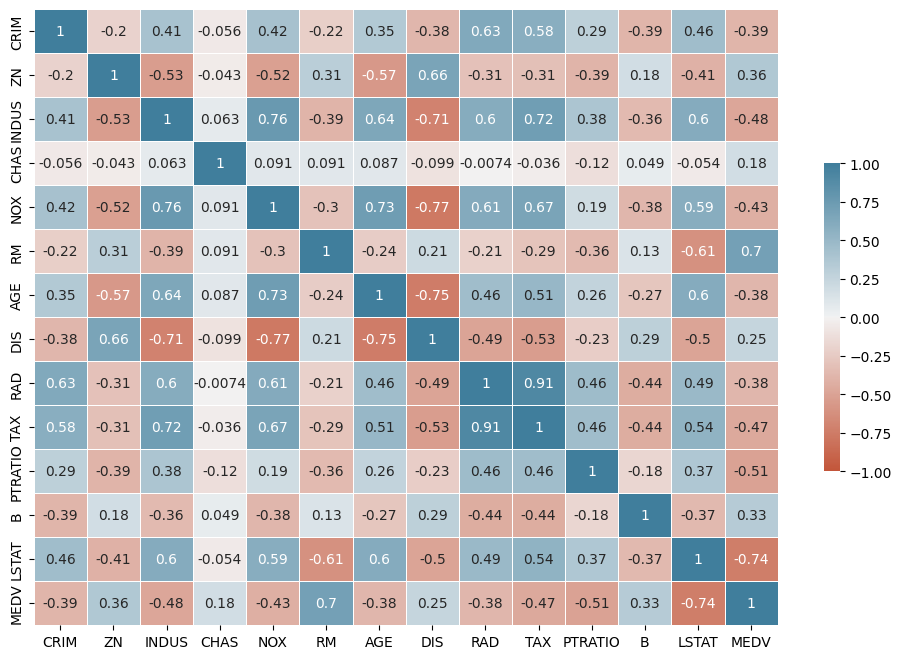

In [8]:
sns.heatmap(
    data=df.corr(),
    cmap=sns.diverging_palette(20, 230, as_cmap=True),
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    cbar_kws={"shrink": 0.5},
    annot=True
)

## 4 - ANALIZAMOS LA VARIABLE CON MAYOR CORRELACIÓN(RM - MEDV)

<Axes: xlabel='RM', ylabel='MEDV'>

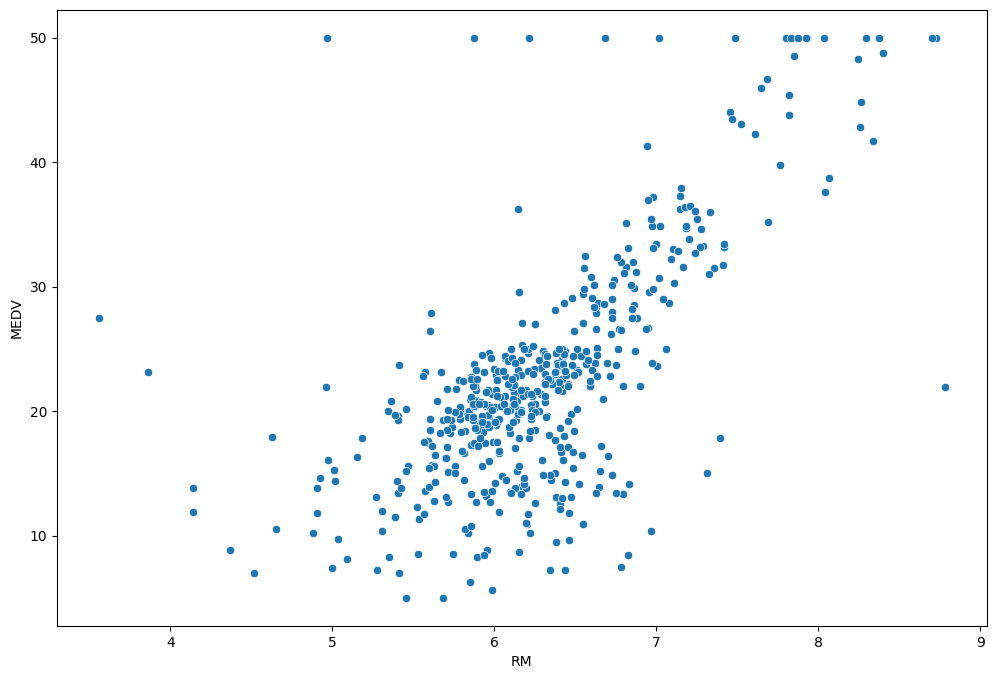

In [9]:
sns.scatterplot(data=df,x=df['RM'],y=df['MEDV'])

## 5 - CREAMOS UN MODELO DE REGRESIÓN LINEAL SIMPLE PARA X = RM Y = MEDV

## 1 - DEFINIR VARIABLE X y Y

* X = RM(PROMEDIO DE HABITACIONES EN EL DEPARTAMENTO)
* Y = MEDV(VALOR PROMEDIO DEL DEPARTAMENTO)

In [10]:
X = df['RM'].values.reshape(-1,1)
y = df['MEDV'].values.reshape(-1,1)

## 1.1 DIVIDIR DATASET EN TRAIN Y TEST

In [11]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [13]:
print(f' X_train(valores de X para entrenamiento) : {X_train.shape[0]}')
print(f' y_train(valores de y para entrenamiento) : {y_train.shape[0]}')
print(f' X_test(valores de X para prueba) : {X_test.shape[0]}')
print(f' y_test(valores de y para prueba) : {y_test.shape[0]}')

 X_train(valores de X para entrenamiento) : 404
 y_train(valores de y para entrenamiento) : 404
 X_test(valores de X para prueba) : 102
 y_test(valores de y para prueba) : 102


# CALCULAMOS PROMEDIO Y STD

In [14]:
print(f'Promedio de X_train : {X_train.mean()}')
print(f'Desviación standard de X_train : {X_train.std()}')

Promedio de X_train : 6.315891089108911
Desviación standard de X_train : 0.7085731779671436


## 1.2 ESTANDARIZAMOS VALORES CON STANDARSCALER

In [15]:
from sklearn.preprocessing import StandardScaler
sc_x = StandardScaler()
X_train = sc_x.fit_transform(X_train)
X_test = sc_x.transform(X_test)

sc_y = StandardScaler()
y_train = sc_y.fit_transform(y_train)
y_test = sc_y.transform(y_test)

In [16]:
print(f'Promedio de X_train : {X_train.mean()}')
print(f'Desviación standard de X_train : {X_train.std()}')

Promedio de X_train : -2.616169107532547e-16
Desviación standard de X_train : 1.0


## 2 - IMPORTAR LIBREARIAS DE SKLEARN

In [17]:
from sklearn.linear_model import LinearRegression

## 3 - CREAMOS EL MODELO Y LO ENTRENAMOS CON LA DATA

In [18]:
slr = LinearRegression()
slr.fit(X_train,y_train)
y_pred = slr.predict(X_train)

## 4 - GRAFICAMOS LOS RESULTADOS

Text(0.5, 0, 'RM')

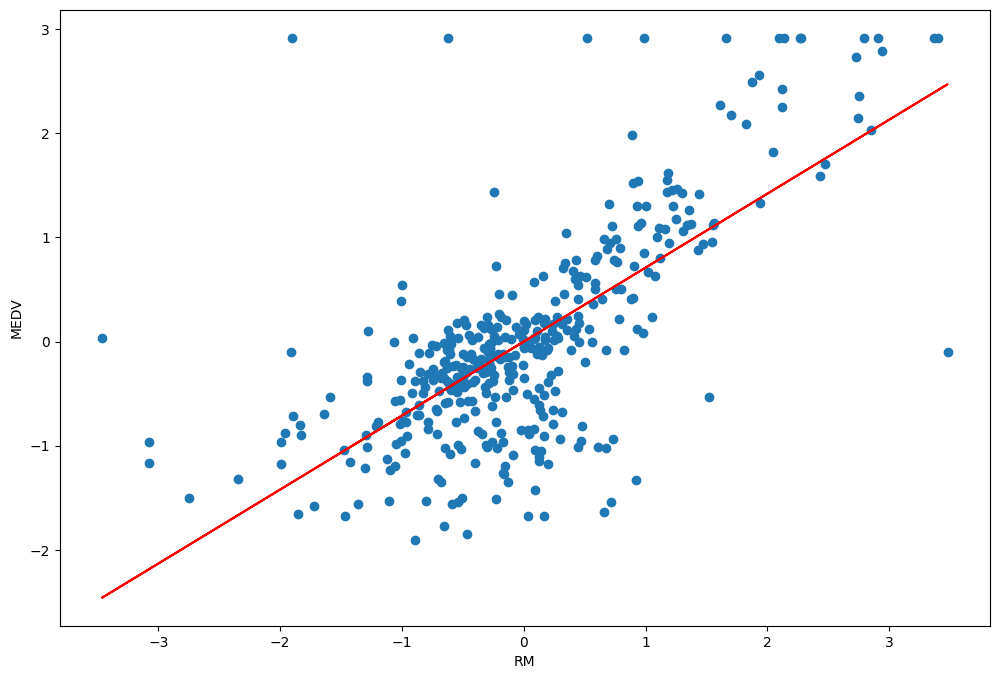

In [19]:
plt.scatter(X_train,y_train)
plt.plot(X_train,y_pred,color='red')
plt.ylabel('MEDV')
plt.xlabel('RM')

## 6 - METRICAS DEL MODELO

In [20]:
y_test_pred = slr.predict(X_test)
y_test_pred.shape

(102, 1)

# 📘 Mean Squared Error (MSE)

El **MSE (Mean Squared Error)** o **Error Cuadrático Medio** mide cuánto se alejan, en promedio, las predicciones del modelo respecto a los valores reales.

Se calcula así:

$
MSE = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2
$

### ✔️ Interpretación
- Siempre es un número **positivo**.
- **Mientras más pequeño**, mejor.
- Un MSE de 0 significa **predicción perfecta**.
- Penaliza más los errores grandes debido al cuadrado.

---

# 📘 Coeficiente de Determinación (R²)

El **R²** mide qué porcentaje de la variabilidad de los datos reales puede explicar el modelo.

La fórmula es:

[$
R^2 = 1 - \frac{SSE}{SST}
$]

Donde:
- $( SSE = $sum (y_i - $hat{y}_i)^2 $) → error del modelo  
- $( SST = $sum (y_i - $bar{y})^2 $) → variación total de los datos  

### ✔️ Interpretación
- R² = 1 → modelo perfecto  
- R² = 0 → el modelo no explica nada  
- R² < 0 → el modelo es peor que predecir la media  
- R² cercano a 1 significa **buena capacidad explicativa**

---

# 📌 Resumen
- **MSE** mide el error promedio del modelo.  
- **R²** mide qué tanto explica el modelo del comportamiento real de los datos.


In [21]:
import sklearn.metrics as metrics

In [22]:
# ERROR CUADRATICO MEDIO
mse = metrics.mean_squared_error(y_test,y_test_pred)
# R2 Coeficiente de determinación
r2 = metrics.r2_score(y_test,y_test_pred)

In [23]:
print(f'El error cuadratico medio(MSE) es de {round(mse,4)}')
print(f'El coeficiente de determinación(R2) es de {round(r2,4)}')

El error cuadratico medio(MSE) es de 0.5312
El coeficiente de determinación(R2) es de 0.3708


In [24]:
num_hab = 4
num_hab_arr = np.array(num_hab).reshape(-1,1)
y_pred_hab = slr.predict(num_hab_arr)
print(f" EL PRECIO PARA UN DPTO CON {num_hab}  ES DE : {y_pred_hab}")

 EL PRECIO PARA UN DPTO CON 4  ES DE : [[2.84271936]]
